In [12]:
import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [13]:
from src.evaluation import build_predictions_report

In [14]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    palette = {"ML": "#1f77b4", "Statistical": "#ff7f0e", "Naive": "#2ca02c"}
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, hue_order=list(palette.keys()), order=df_sorted[y],
                dodge=False, palette=palette if hue else None, ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [15]:
!ls ../artifacts/models/

level_01_daily_total_sales_artifact.pkl
level_04_daily_dept_sales_artifact.pkl
level_06_daily_store_sales_artifact.pkl
level_09_daily_store_dept_sales_artifact.pkl


In [16]:
ARTIFACT = "level_04_daily_dept_sales_artifact"

In [17]:
import joblib

from src.data.split import reconstruct_test_data

artifact_path = f"../artifacts/models/{ARTIFACT}.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

X_test, y_test, artifact["train"], artifact["test"] = reconstruct_test_data(artifact)

2026-09-03 20:01:09.623 | INFO     | src.data.split:load_data:359 - level_04_daily_dept | target=sales | 13,587 filas | 191 features (9 categóricas)
2026-09-03 20:01:09.726 | INFO     | src.data.split:log_summary:48 - Train : 2011-01-29 to 2016-03-27 (1,885 days, 13,195 rows)
2026-09-03 20:01:09.728 | INFO     | src.data.split:log_summary:49 - Valid : 2016-03-28 to 2016-04-24 (28 days, 196 rows)
2026-09-03 20:01:09.731 | INFO     | src.data.split:log_summary:50 - Test  : 2016-04-25 to 2016-05-22 (28 days, 196 rows)
2026-09-03 20:01:10.257 | INFO     | src.data.split:split_data:421 - Features: 191 (9 categóricas)


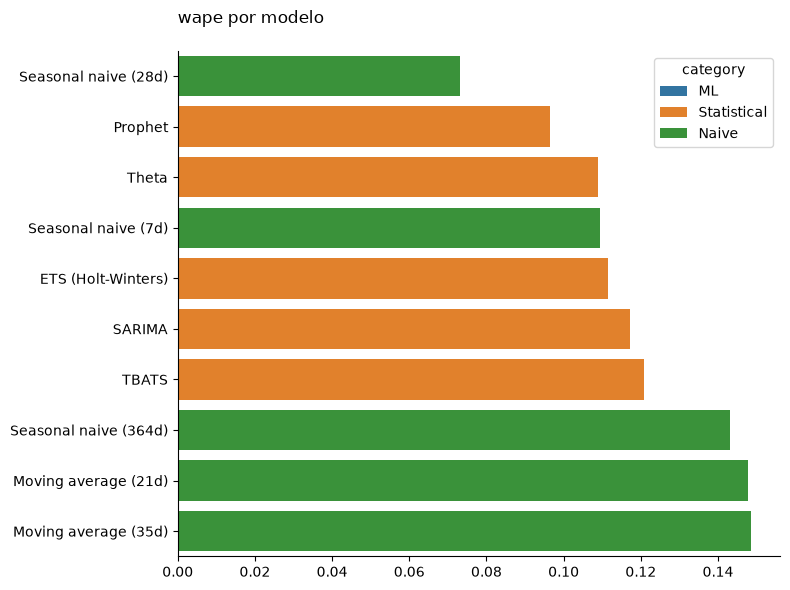

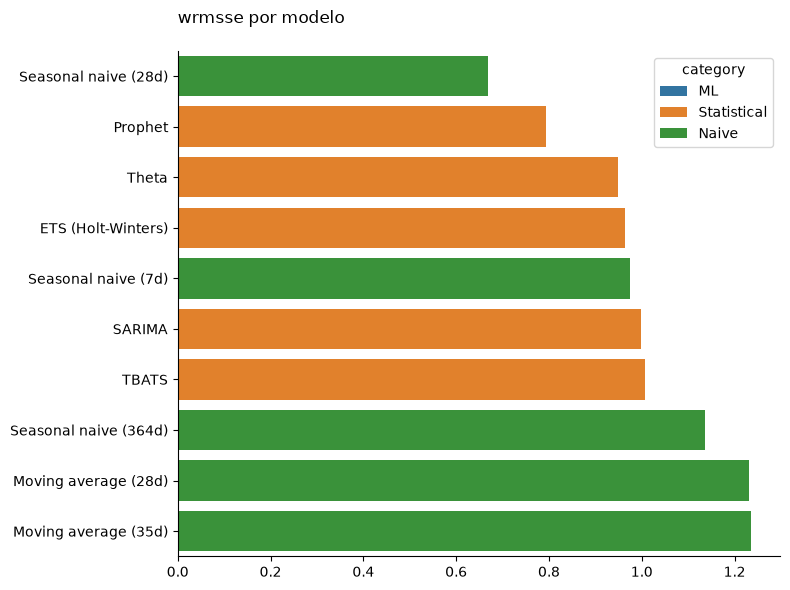

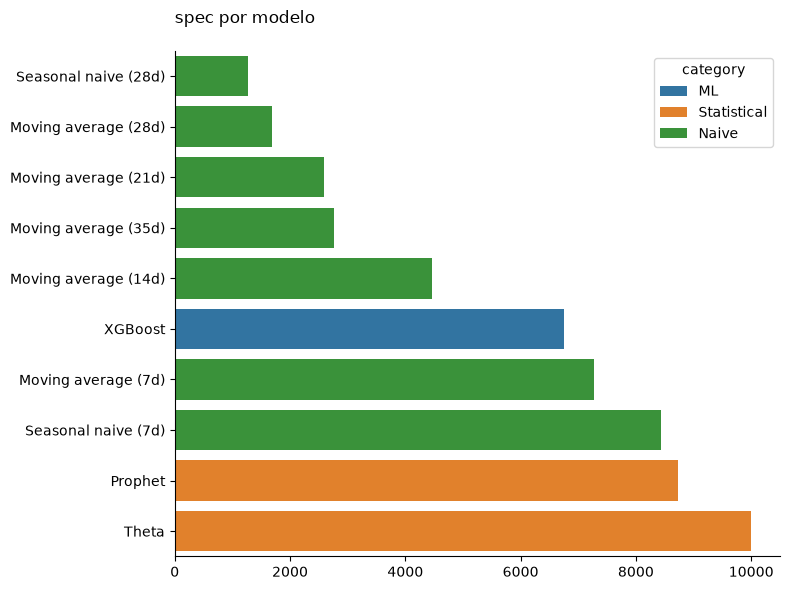

In [18]:
#['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
for col in ['wape', 'wrmsse', 'spec']:
    plot_barh_by_model(results_df.nsmallest(10, col), hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [19]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(300_000, len(X_test)), random_state=42)

shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                             feature  mean_abs_shap
51                   te_weekend_mean    2222.121709
87                             lag28     726.662081
1                            dept_id     330.415164
52                      te_snap_mean     225.668945
93                            lag364     190.450350
..                               ...            ...
100   rolling_min_lag1_window_size14       0.000000
115  rolling_mean_lag2_window_size14       0.000000
155  rolling_mean_lag7_window_size14       0.000000
139  rolling_mean_lag5_window_size14       0.000000
153    rolling_min_lag7_window_size7       0.000000

[191 rows x 2 columns]


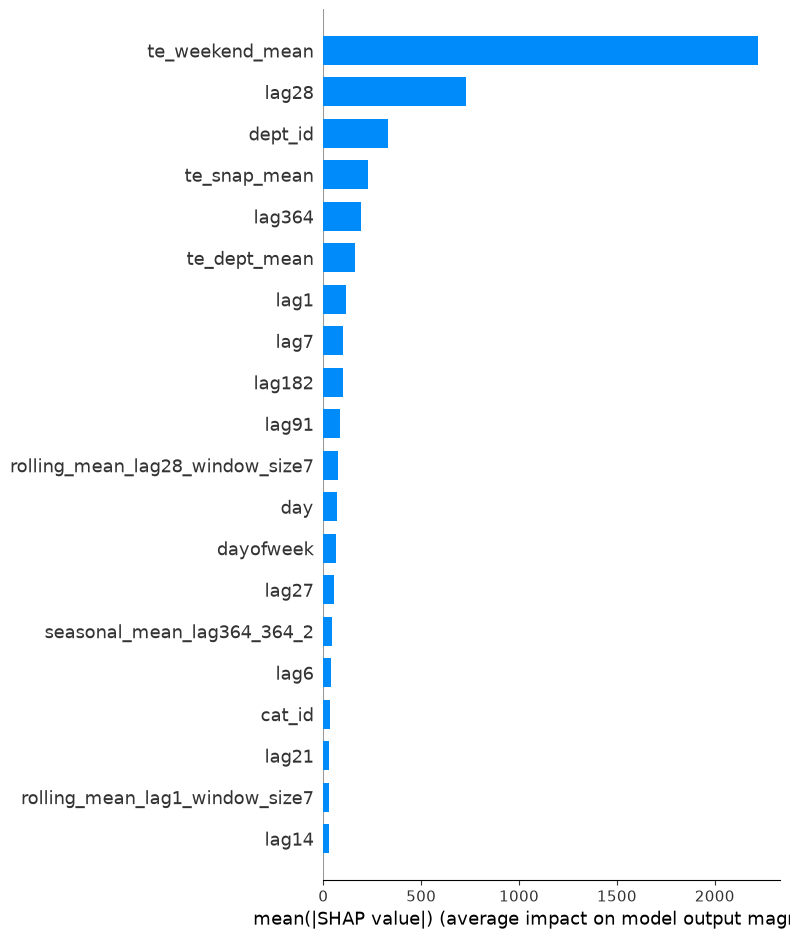

In [20]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

In [21]:
#shap.summary_plot(shap_values, X_shap)

# Predicciones

In [22]:
from src.evaluation import analizar_prediccion, plot_forecast

In [23]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Total sales: {df_pred['sales'].sum():,.0f}")
print(f"Total predicted: {df_pred['y_pred'].sum():,.0f}")
print(f"Diff: {df_pred['y_pred'].sum() - df_pred['sales'].sum():,.0f}")

print(f"Test WAPE: {metrics_test_final['wape']:.1%}")
print(f"Test BIAS: {metrics_test_final['bias']:.1%}")

print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.3f}")

Total sales: 1,231,764
Total predicted: 1,189,137
Diff: -42,627
Test WAPE: 7.4%
Test BIAS: -3.5%
Test WRMSSE: 0.665


In [24]:
from src.evaluation import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])
df_metrics.head(5)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
FOODS_3_FOODS,28,28,564926.0,541438.0,23488.0,28734.0,1.379273e+06,0.353571,0.050863,-0.041577,0.068379,22.888007,0.538406,0.462190,5910.776786
HOUSEHOLD_1_HOUSEHOLD,28,28,222327.0,221808.0,519.0,11575.0,8.708510e+05,0.223239,0.052063,-0.002334,0.071300,1.255464,0.468061,0.473853,262.303571
FOODS_2_FOODS,28,28,165203.0,159317.0,5886.0,13204.0,5.728573e+05,0.146850,0.079926,-0.035629,0.105469,12.481672,1.103303,0.845503,1581.803571
HOBBIES_1_HOBBIES,28,28,102554.0,100715.0,1839.0,7563.0,4.758871e+05,0.121992,0.073747,-0.017932,0.093187,6.808409,0.589754,0.661404,627.892857
HOUSEHOLD_2_HOUSEHOLD,28,28,61093.0,60851.0,242.0,2538.0,2.914828e+05,0.074720,0.041543,-0.003961,0.048754,2.669819,0.384386,0.410160,127.919643


In [25]:
df_metrics.sort_values('wape').round(4)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
HOUSEHOLD_2_HOUSEHOLD,28,28,61093.000000,60851.0,242.0,2538.0,2.914828e+05,0.0747,0.0415,-0.0040,0.0488,2.6698,0.3844,0.4102,127.9196
FOODS_3_FOODS,28,28,564926.000000,541438.0,23488.0,28734.0,1.379273e+06,0.3536,0.0509,-0.0416,0.0684,22.8880,0.5384,0.4622,5910.7768
HOUSEHOLD_1_HOUSEHOLD,28,28,222326.984375,221808.0,519.0,11575.0,8.708510e+05,0.2232,0.0521,-0.0023,0.0713,1.2555,0.4681,0.4739,262.3036
HOBBIES_1_HOBBIES,28,28,102554.000000,100715.0,1839.0,7563.0,4.758871e+05,0.1220,0.0737,-0.0179,0.0932,6.8084,0.5898,0.6614,627.8929
FOODS_2_FOODS,28,28,165203.000000,159317.0,5886.0,13204.0,5.728573e+05,0.1468,0.0799,-0.0356,0.1055,12.4817,1.1033,0.8455,1581.8036
FOODS_1_FOODS,28,28,102359.000000,83227.0,19132.0,19132.0,2.832728e+05,0.0726,0.1869,-0.1869,0.2205,28.0000,1.6054,2.0289,16743.4018
HOBBIES_2_HOBBIES,28,28,13302.000000,21781.0,-8479.0,8479.0,2.735192e+04,0.0070,0.6374,0.6374,0.5281,-28.0000,5.5619,6.7242,3055.7500


/tmp/ipykernel_7991/3753011339.py:2: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df_sample = df_pred.query(f'series_id == "{SERIES}"').round(2).copy()


,series_id,date,sales,gross_sales,y_pred,error,abs_error,wape,bias
13395,FOODS_3_FOODS,2016-04-25,18155.0,43708.128906,16949.0,1206.0,1206.0,0.07,-0.07
13402,FOODS_3_FOODS,2016-04-26,15997.0,38946.281250,15650.0,347.0,347.0,0.02,-0.02
13409,FOODS_3_FOODS,2016-04-27,15962.0,38628.011719,15787.0,175.0,175.0,0.01,-0.01
13415,FOODS_3_FOODS,2016-04-28,15642.0,37746.460938,16284.0,-642.0,642.0,0.04,0.04
13419,FOODS_3_FOODS,2016-04-29,18895.0,45512.710938,18982.0,-87.0,87.0,0.00,0.00
13426,FOODS_3_FOODS,2016-04-30,22527.0,54235.660156,23069.0,-542.0,542.0,0.02,0.02
13436,FOODS_3_FOODS,2016-05-01,23955.0,59245.808594,24083.0,-128.0,128.0,0.01,0.01
13444,FOODS_3_FOODS,2016-05-02,19252.0,46926.800781,18800.0,452.0,452.0,0.02,-0.02
13453,FOODS_3_FOODS,2016-05-03,19278.0,46562.839844,18561.0,717.0,717.0,0.04,-0.04
13456,FOODS_3_FOODS,2016-05-04,18187.0,43963.839844,18127.0,60.0,60.0,0.00,-0.00


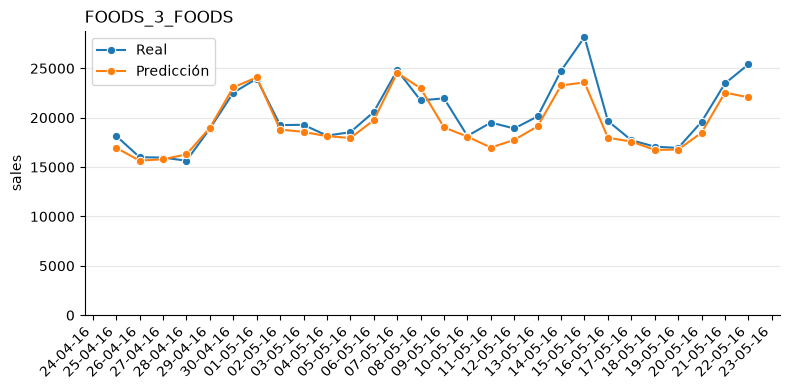

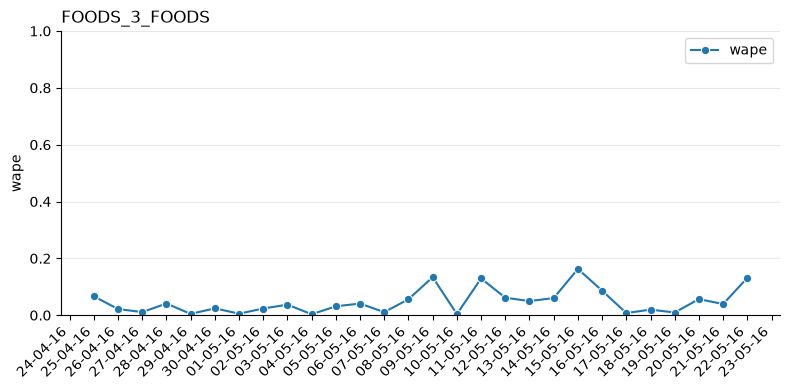

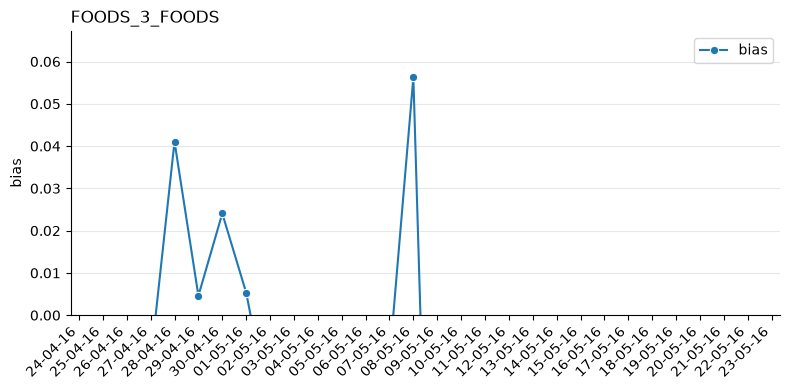

In [26]:
SERIES = 'FOODS_3_FOODS'
df_sample = df_pred.query(f'series_id == "{SERIES}"').round(2).copy()

display(df_sample)

top_best_dates = df_pred.query(f'series_id == "{SERIES}"').nsmallest(2, 'wape')['date']
top_error_dates = df_pred.query(f'series_id == "{SERIES}"').nlargest(2, 'wape')['date']

plot_forecast(df_pred, 'sales', series_id=SERIES)
plot_forecast(df_pred, 'wape', series_id=SERIES)
plot_forecast(df_pred, 'bias', series_id=SERIES)

################################################## Date: 2016-05-15 00:00:00 ##################################################


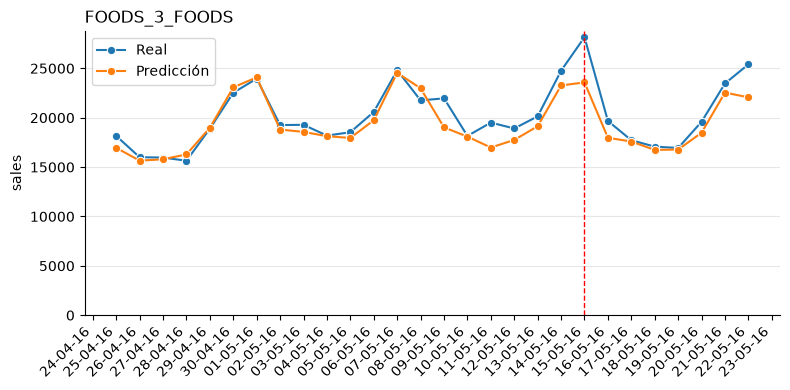

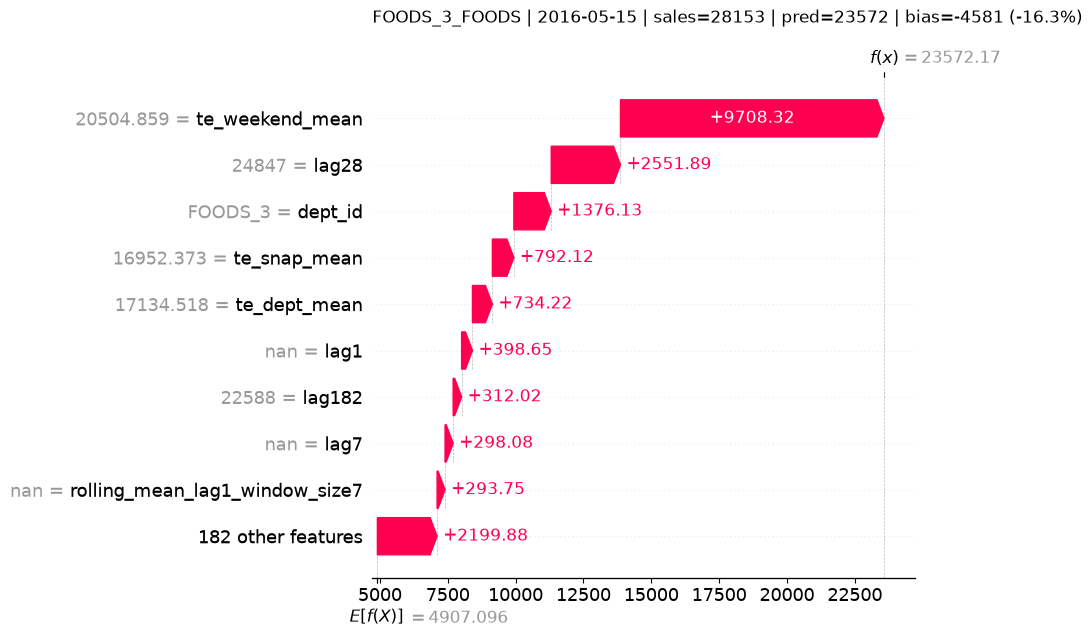

################################################## Date: 2016-05-09 00:00:00 ##################################################


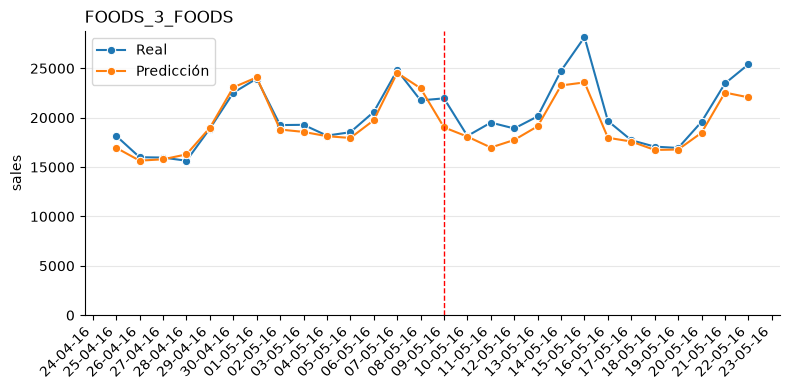

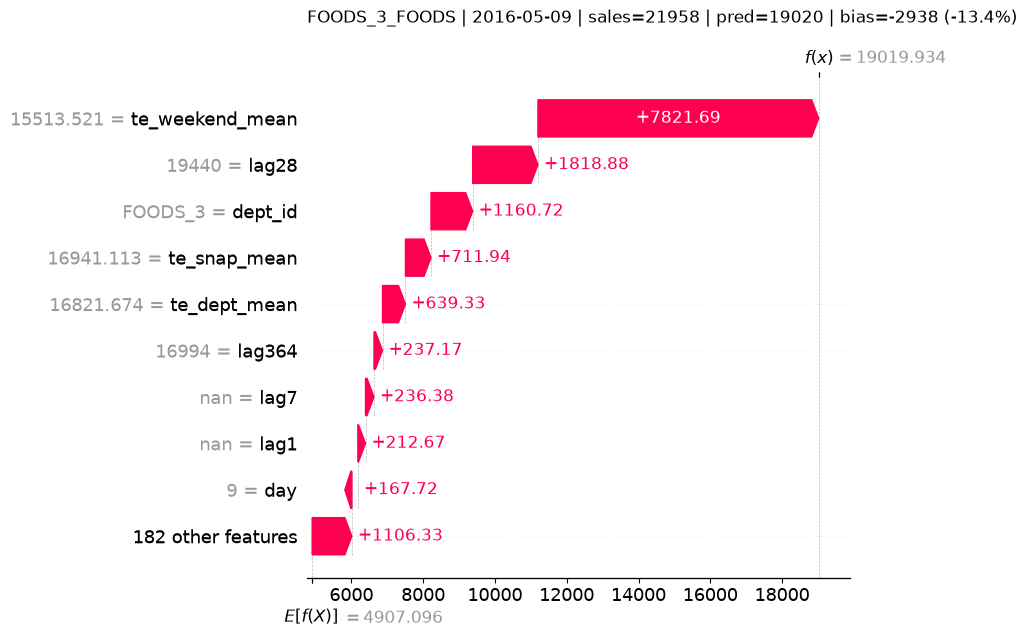

In [27]:
for i in top_error_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)

################################################## Date: 2016-05-04 00:00:00 ##################################################


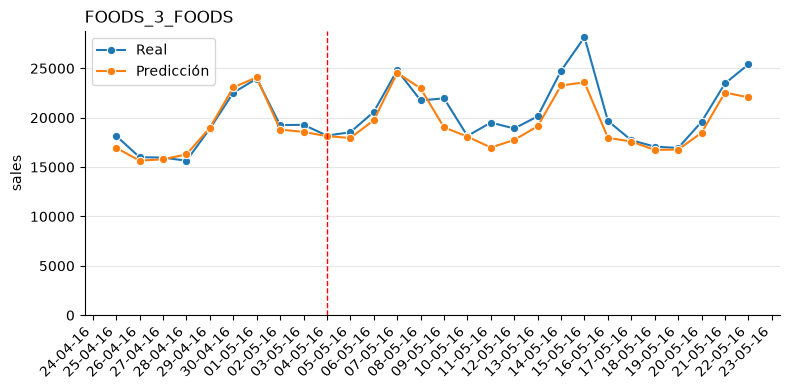

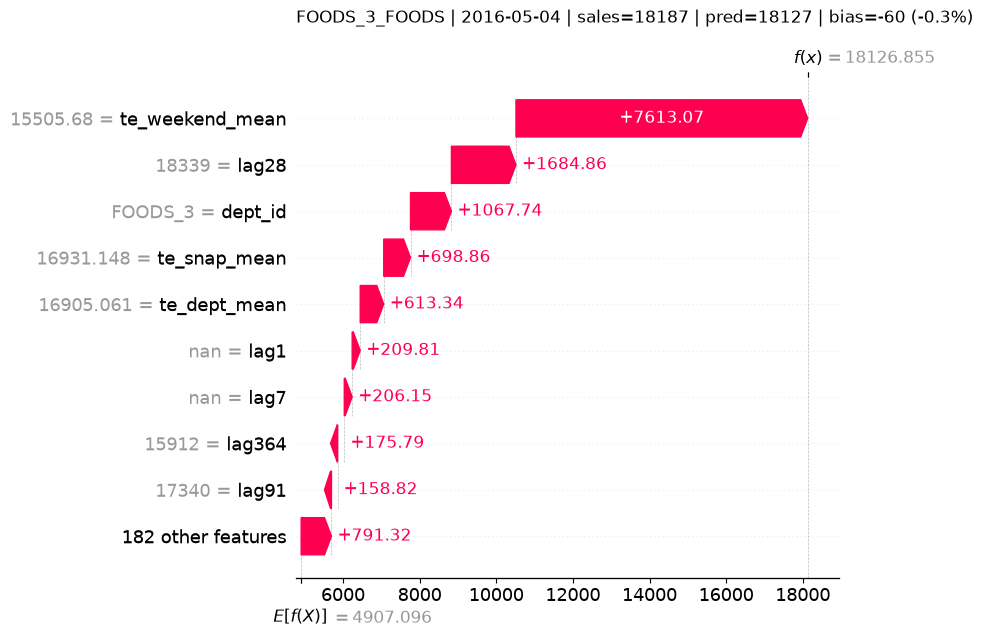

################################################## Date: 2016-05-10 00:00:00 ##################################################


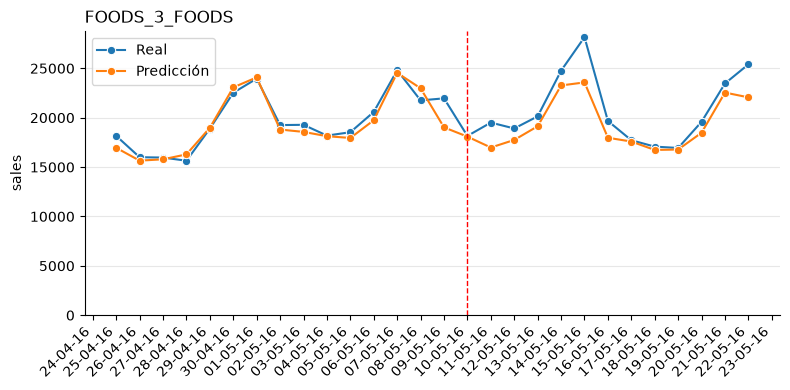

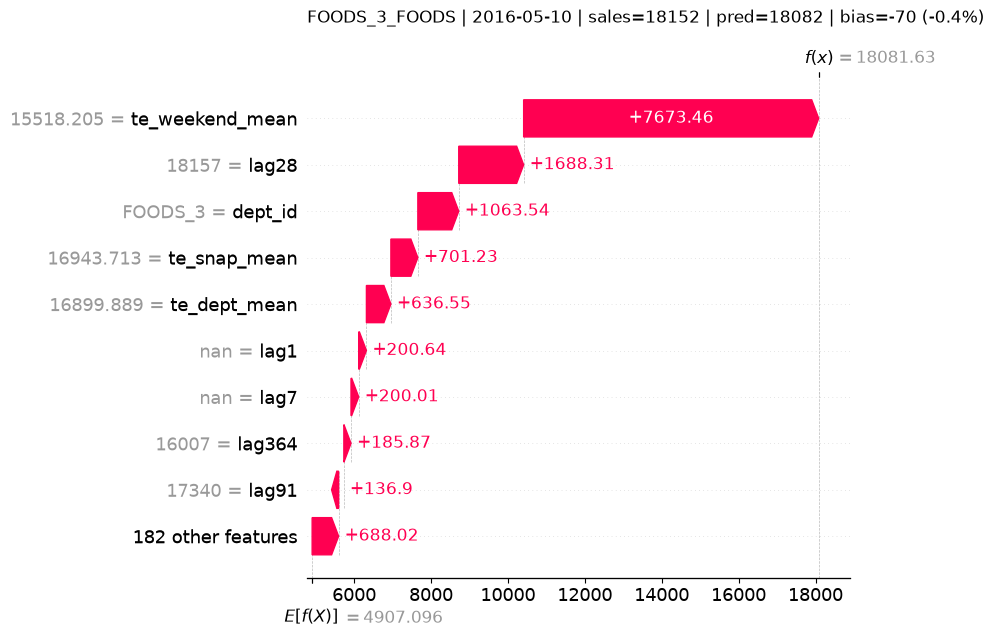

In [28]:
for i in top_best_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)